Imports and config (always run this first)

In [18]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter("ignore", FutureWarning)
import sys
sys.path.append('/mnt/md0/tempFolder/samAnderson/unet-gnn/')
sys.path.append('/mnt/md0/tempFolder/samAnderson/unet-gnn/functions/')
from config import cognition_config as cfg
from postprocessing import PostProcessor

# Create a function that changes names in df for better visualization
def clean_cog_df(df, sort_by=None, sort_cohort='AD'):
    
    # Rename for visualizations
    df = df.copy()
            
    # Replace certain tests to make them more readable
    if 'test' in df.columns:
        df['test'] = df['test'].replace({
            'DIGITSCOR': 'DSST',
            'RAVLT_immediate': 'RAVLT Immediate Recall',
            'TRABSCOR': 'TMT-B',
            'RAVLT_learning': 'RAVLT Learning',
            'RAVLT_perc_forgetting': 'RAVLT Forgetting %',
            'EcogSPTotal': 'Everyday Cog. Partner-Eval',
            'LDELTOTAL': 'Logical Mem. Delayed Recall',
            'EcogPtTotal': 'Everyday Cog. Self-Eval',
            'MOCA': 'MoCA'
        })
    
    # Replace certain regions or networks to make them more readable
    location_map = {
        'G_postcentral' : 'Postcentral Gyrus',
        'G_precuneus' : 'Precuneus',
        'Pole_temporal': 'Temporal Pole',
        'G_oc-temp_med-Parahip': 'Parahippocampal Gyrus',
        'G_temporal_inf': 'Inferior Temporal Gyrus',
        'S_orbital_lateral': 'Orbital Lateral Sulcus',
        'dmn' : 'Default Mode Network',
        'fpn' : 'Frontoparietal Network',
        'visual' : 'Visual Network',
        'somatomotor' : 'Somatomotor Network'
    }
    df['location'] = df['location'].replace(location_map)
        
    # Replace hemis to make them more readable
    if 'hemi' in df.columns:
        df['hemi'] = df['hemi'].replace({
            'lh': 'Left',
            'rh': 'Right',
            'avg': 'Avg'
        })
    
    # Indicate when test is inverted visually by adding -1 x
    df['is_inverted'] = df['test'].map(cfg.test_relations).fillna(False)
    df['test_display'] = df['test']
    df.loc[df['is_inverted'], 'test_display'] = (
        '-1 x ' + df.loc[df['is_inverted'], 'test_display'].astype(str)
    )

    # Sort based on given ROI
    if sort_by is not None:
        
        # Map sort_by to renamed value if needed
        if sort_by in location_map:
            sort_by = location_map[sort_by]

        # Use sort_by directly (names already updated above)
        target_df = df[df['location'] == sort_by].copy()
        
        if len(target_df) > 0:
            target_df_sort = target_df if sort_cohort is None else target_df[target_df['cohort'] == sort_cohort]

            agg_df = (
                target_df_sort
                .groupby('test_display')
                .agg(
                    coef=('coef', 'mean'),
                    adj_pval=('adj_pval', 'min')
                )
            )
            agg_df['is_sig'] = agg_df['adj_pval'] < 0.05
            agg_df['abs_coef'] = agg_df['coef'].abs()

            order = (
                agg_df
                .sort_values(
                    by=['is_sig', 'abs_coef'],
                    ascending=[False, False]
                )
                .index.tolist()
            )
                        
            # Apply ordering as categorical (controls plotting order)
            df['test_display'] = pd.Categorical(
                df['test_display'],
                categories=order,
                ordered=True
            )
            df = df.sort_values('test_display')

        else:
            print(f"[clean_cog_df] Warning: sort_by='{sort_by}' not found in location column.")

    return df

def plot_barplots(local_results, output_path=None, cohort_order=None):
    if cohort_order is None:
        cohort_order = list(local_results['cohort'].drop_duplicates())

    target_cohort = cohort_order[-1]

    def bold_significant_bars(df, ax, active_cohorts, region_order, pval_thresh=0.05):
        pmap = df.set_index(['test_display', 'cohort'])['adj_pval'].to_dict()
        n_tests = len(region_order)
        n_cohorts = len(active_cohorts)

        for idx, bar in enumerate(ax.patches):
            cohort_idx = idx // n_tests
            test_idx = idx % n_tests

            if cohort_idx >= n_cohorts:
                break

            cohort = active_cohorts[cohort_idx]
            test_label = region_order[test_idx]

            pval = pmap.get((test_label, cohort), 1.0)
            if pval < pval_thresh:
                x0, y0 = bar.get_x(), bar.get_y()
                width, height = bar.get_width(), bar.get_height()
                ax.add_patch(plt.Rectangle(
                    (x0, y0), width, height,
                    fill=False, linewidth=2.5,
                    edgecolor='black', zorder=10
                ))
                bar.set_linewidth(2)
                bar.set_edgecolor('black')

    sns.set(style='whitegrid')
    region_list = local_results['location'].drop_duplicates().sort_values()
    n_plots = len(region_list)
    n_cols = 2
    n_rows = (n_plots + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 6*n_rows), sharex=True)
    axes = axes.flatten()

    if hasattr(local_results['test_display'], 'cat'):
        global_order = local_results['test_display'].cat.categories.tolist()
    else:
        global_order = (
            local_results
            .groupby('test_display')['coef'].mean()
            .sort_values(ascending=False).index.tolist()
        )

    # Compute rank_map ONCE before the loop
    # rank_map[test_display][location] = rank (1 = highest coef across regions)
    ad_data = local_results[local_results['cohort'] == target_cohort]
    sig_ad = ad_data[ad_data['adj_pval'] < 0.05]
    rank_map = {}
    for test, group in sig_ad.groupby('test_display'):
        ranks = group.set_index('location')['coef'].rank(ascending=False).astype(int)
        rank_map[test] = ranks.to_dict()

    for i, (region, ax) in enumerate(zip(region_list, axes)):
        data_region = local_results[local_results['location'] == region]
        active_cohorts = [c for c in cohort_order if c in data_region['cohort'].values]
        region_tests = data_region['test_display'].unique()
        region_order = [t for t in global_order if t in region_tests]

        if hasattr(local_results['test_display'], 'cat'):
            region_order = [t for t in local_results['test_display'].cat.categories if t in region_tests]

        sns.barplot(data=data_region, y='test_display', x='coef', hue='cohort',
                    hue_order=active_cohorts, palette='Set2', ax=ax,
                    order=region_order)

        bold_significant_bars(data_region, ax, active_cohorts, region_order)
        
        # Formatting
        ax.set_xlim(-0.4, 1.5)
        ax.set_title(region, fontsize=12)
        
        if i % n_cols != 0:
            ax.set_yticks([])
        if i < n_plots - n_cols:
            ax.tick_params(axis='x', labelbottom=False)
        ax.set_xlabel('β', size=14)
        ax.set_ylabel('')
        if i != len(region_list)-1:
            ax.legend_.remove()

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
        
    # Update legend
    ax.legend(
        title='Cohort',
        fontsize=12,
        title_fontsize=12,
        markerscale=1.5
    )

    plt.tight_layout()
    if output_path:
        fig.savefig(output_path, dpi=1200, pil_kwargs={'quality': 95})
    return fig

# Create the postprocessing object
p = PostProcessor(first='rh')

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


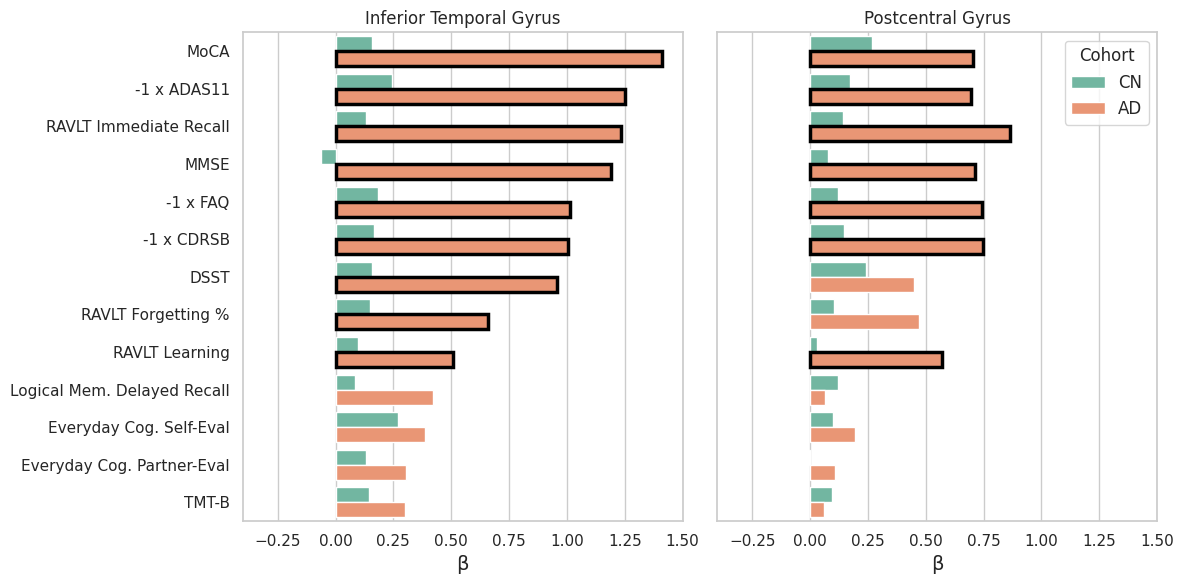

In [19]:
# Get all region masks
region_masks = p.get_locations(
    arr=None,
    per='region',
    return_type='mask'
)

# Get all network masks
network_masks = p.get_locations(
    arr=None,
    per='network',
    return_type='mask'
)

target_rois = {'G_postcentral',
               'G_temporal_inf'
               } 

# Sub-select networks for analysis
target_networks = {}

selected_masks = {}

# Combine hemispheres for regions
for (region, hemi), mask in region_masks.items():
    if region not in target_rois:
        continue

    if region not in selected_masks:
        selected_masks[region] = mask.copy()
    else:
        selected_masks[region] |= mask  # combine via logical OR

# Add networks (no hemisphere split)
for network, mask in network_masks.items():
    if network not in target_networks:
        continue

    selected_masks[network] = mask.copy()

# Update config to include targets
cfg.masks = selected_masks

# Regress masked LBAGs against cognitive scores
cog_df = p.regress_cognitive(cfg)

# Clean df for plotting
cog_df = clean_cog_df(cog_df, sort_by='G_temporal_inf')

# Remove accidental region column if present (we only use 'location')
cog_df = cog_df.drop(columns=['region'], errors='ignore')

# Make directories
os.makedirs(f'{cfg.cross_cohort_path}arrays/', exist_ok=True)
os.makedirs(f'{cfg.cross_cohort_path}visualizations/', exist_ok=True)

# Save the df, plot this, and save the plot
cog_df.to_csv(f'{cfg.cross_cohort_path}arrays/cog_df.csv', index=False)

fig = plot_barplots(
    cog_df,
    output_path=f'{cfg.cross_cohort_path}visualizations/combined_cog_barplot.png',
    cohort_order=list(cfg.cohort_dict.keys())
)